GREGORY NEWTON BACKWARD 

Interpolating Polynomial: 0.0338541666667266*x**5 - 0.0625000000004326*x**4 + 0.361979166667896*x**3 + 0.312499999998285*x**2 + 1.08746666666784*x + 0.984999999999683
Value at x = 1.68: 5.36550757760000


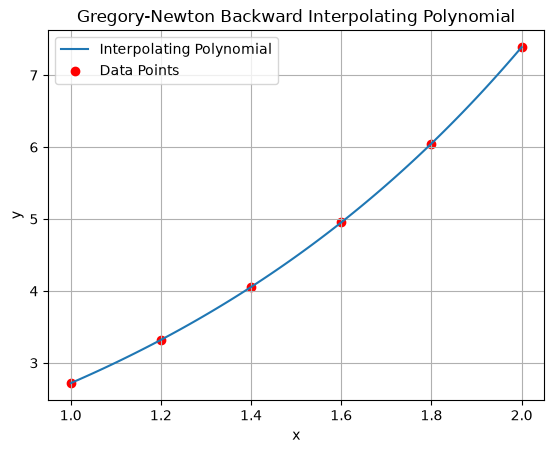

In [7]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt


def backward_difference_table(y_values):
    n = len(y_values)
    table = np.zeros((n, n))
    table[:, 0] = y_values

    for j in range(1, n):
        for i in range(n - j):
            table[i][j] = table[i + 1][j - 1] - table[i][j - 1]

    return table


def gregory_newton_backward(x_values, y_values):
    n = len(x_values)
    h = x_values[1] - x_values[0]  # Assuming equal spacing
    x = sp.Symbol('x')
    u = (x - x_values[-1]) / h  # Using last point for backward formula

    table = backward_difference_table(y_values)
    polynomial = table[n - 1, 0]

    fact = 1
    term = 1

    for i in range(1, n):
        fact *= i
        term *= (u + (i - 1))
        polynomial += (table[n - 1 - i, i] / fact) * term

    polynomial = sp.simplify(polynomial)
    return polynomial


# Example usage
#x_values = np.array([0, 1, 2, 3, 4])
#y_values = np.array([1, 2, 0, 5, 3])

#x_values = np.array([2, 2.05, 2.10, 2.15, 2.20, 2.25])  # x-values of data points
#y_values = np.array([0.69315, 0.71784, 0.74192, 0.76547, 0.78846, 0.81093])  # y-values of data points

#x_values = np.array([-2, -1, 0, 1, 2, 3])  # x-values of data points
#y_values = np.array([9, 16, 17, 18, 44, 81])  # y-values of data points

x_values = np.array([1, 1.2, 1.4, 1.6, 1.8, 2])  # x-values of data points
y_values = np.array([2.7183, 3.3201, 4.0552, 4.9530, 6.0496, 7.3891])  # y-values of data points


polynomial = gregory_newton_backward(x_values, y_values)
print("Interpolating Polynomial:", polynomial)


# Evaluate at x = ---
x_val = 1.68
y_at_x_val = polynomial.subs(sp.Symbol('x'), x_val)
print(f"Value at x = {x_val}: {y_at_x_val}")


# Plot the polynomial
x_range = np.linspace(min(x_values), max(x_values), 100)
y_range = [polynomial.subs(sp.Symbol('x'), x) for x in x_range]

plt.plot(x_range, y_range, label='Interpolating Polynomial')
plt.scatter(x_values, y_values, color='red', label='Data Points')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gregory-Newton Backward Interpolating Polynomial')
plt.legend()
plt.grid()
plt.show()

or